# FreeSurfer ROI extraction → simnibs-reader

Ce notebook montre comment extraire des ROI depuis FreeSurfer et les utiliser
directement avec `simnibs-reader` pour masquer un champ électrique.

**Workflow général :**
```
FreeSurfer segmentation
   (aparc+aseg.mgz / .annot)
          │
          ▼
   masque binaire NIfTI  (.nii.gz)
          │
          ▼
   efield.get_roi(mask=...)       ← simnibs-reader gère le resampling
          │
          ▼
   ROI  →  .stats() / .postprocess() / .save()
```

**Sections :**
- **A** : ROI volumétrique depuis `aparc+aseg.mgz`
- **B** : ROI surfacique depuis `.annot` (projetée en volume)
- **C** : ROI sphérique en espace natif
- **D** : Intégration simnibs-reader — espace natif (subject_volumes)
- **E** : Intégration simnibs-reader — espace MNI (mni_volumes)

In [3]:
import sys
sys.path.insert(0, '/Users/hippolyte.dreyfus/Documents/simnibs-reader')

from pathlib import Path
import numpy as np
import nibabel as nib
from nilearn import image, plotting
import simnibs_reader as snr

# ── Paths ───────────────────────────────────────────────────────────────────
FS_DIR      = Path('/Volumes/levy/raw/valerocabre/stimSD/Data/derivatives/mri/freesurfer2')
SUBJECT     = 'sub-0003'
fs_sub      = FS_DIR / SUBJECT

SIMNIBS_DIR = Path('/Volumes/levy/raw/valerocabre/stimSD/Data/derivatives/mri/2-simnibs-simu-left/0001')
SIMU_DIR    = SIMNIBS_DIR / 'simulations' / 'simulation_AFFT-left_8dbde024'
M2M_DIR     = SIMNIBS_DIR / 'm2m_0001'

# Dossier de sortie pour les masques
MASKS_OUT   = Path('masks')
MASKS_OUT.mkdir(exist_ok=True)

---
## A — ROI volumétrique depuis `aparc+aseg.mgz`

La méthode la plus directe : chaque voxel est déjà labellisé par FreeSurfer.
On extrait le label voulu → masque binaire → sauvegarde `.nii.gz`.

In [2]:
# Labels aparc+aseg courants
# Référence complète : https://surfer.nmr.mgh.harvard.edu/fswiki/FsTutorial/AnatomicalROI/FreeSurferColorLUT
APARC_LABELS = {
    'lh_precentral'      : 1024,   # M1
    'lh_postcentral'     : 1022,   # S1
    'lh_superiorfrontal' : 1028,   # DLPFC approx
    'lh_parsopercularis' : 1018,   # IFG pars opercularis
    'lh_superiorparietal': 1029,   # SPL
    'lh_FEF_approx'      : 1003,   # caudal middle frontal → FEF
    'rh_precentral'      : 2024,
    'rh_postcentral'     : 2022,
    'rh_superiorfrontal' : 2028,
    'lh_thalamus'        : 10,
    'lh_putamen'         : 12,
    'lh_hippocampus'     : 17,
}

M1 lh — n voxels : 10676


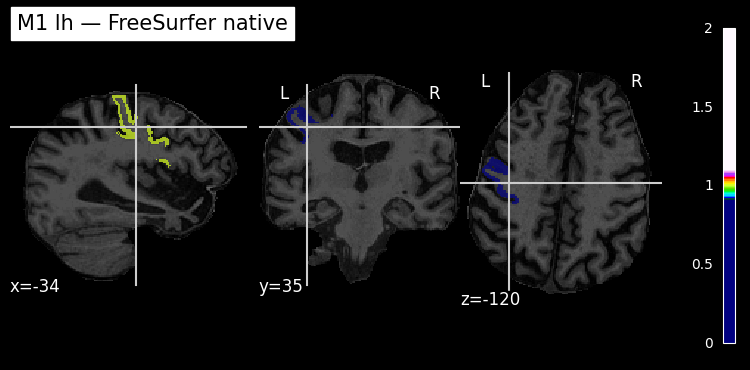

In [11]:
def fs_label_to_mask(label: int, aparc_img: nib.Nifti1Image) -> nib.Nifti1Image:
    """Masque binaire NIfTI pour un label aparc+aseg."""
    mask = (aparc_img.get_fdata() == label).astype(np.uint8)
    return nib.Nifti1Image(mask, aparc_img.affine, aparc_img.header)


aparc_aseg = nib.load(fs_sub / 'mri' / 'aparc+aseg.mgz')

# Exemple : M1 gauche
M1_lh = fs_label_to_mask(APARC_LABELS['lh_precentral'], aparc_aseg)
print(f'M1 lh — n voxels : {M1_lh.get_fdata().sum():.0f}')

# Sauvegarder en NIfTI (nécessaire pour simnibs-reader)
mask_path_M1 = MASKS_OUT / 'M1_lh_native_fs.nii.gz'
nib.save(M1_lh, mask_path_M1)

plotting.plot_roi(M1_lh, bg_img=fs_sub / 'mri' / 'brain.mgz',
                  title='M1 lh — FreeSurfer native', display_mode='ortho')
plotting.show()

---
## TODO B — ROI surfacique depuis `.annot` (projetée en volume)

Plus précis anatomiquement. On récupère les vertices de la région,
puis on les projette dans le volume via `mri_surf2vol` (FreeSurfer)
ou en rasterisant directement les coordonnées 3D.

In [14]:
import nibabel as nib
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


def get_surface_roi_mask(region: str, hemi: str, fs_subject: Path,
                          atlas: str = 'aparc') -> tuple[np.ndarray, np.ndarray]:
    annot_path = fs_subject / 'label' / f'{hemi}.{atlas}.annot'
    labels, ctab, names = nib.freesurfer.read_annot(annot_path)
    names_decoded = [n.decode() for n in names]
    if region not in names_decoded:
        raise ValueError(f'{region!r} introuvable. Disponibles : {names_decoded}')
    idx = names_decoded.index(region)
    vertex_mask = labels == idx
    coords, _ = nib.freesurfer.read_geometry(fs_subject / 'surf' / f'{hemi}.pial')
    return vertex_mask, coords[vertex_mask]


def surface_roi_to_volume(region: str, hemi: str, fs_subject: Path,
                           ref_img: nib.Nifti1Image,
                           atlas: str = 'aparc') -> nib.Nifti1Image:
    _, coords_ras = get_surface_roi_mask(region, hemi, fs_subject, atlas)
    affine_inv = np.linalg.inv(ref_img.affine)
    mask_data  = np.zeros(ref_img.shape[:3], dtype=np.uint8)

    for xyz in coords_ras:
        vox = np.round(affine_inv @ np.append(xyz, 1))[:3].astype(int)
        if all(0 <= vox[i] < ref_img.shape[i] for i in range(3)):
            mask_data[vox[0], vox[1], vox[2]] = 1

    return nib.Nifti1Image(mask_data, ref_img.affine)

t1_fs = nib.load(fs_sub / 'mri' / 'brain.mgz')

M1_surf_vol = surface_roi_to_volume('precentral', 'lh', fs_sub, ref_img=t1_fs)
print(f'M1 lh surface→volume — n voxels : {M1_surf_vol.get_fdata().sum():.0f}')

mask_path_M1_surf = MASKS_OUT / 'M1_lh_surface_native_fs.nii.gz'
nib.save(M1_surf_vol, mask_path_M1_surf)


M1 lh surface→volume — n voxels : 0


---
## TODO C — ROI sphérique en espace natif FreeSurfer

Utile quand on a des coordonnées RAS issues d'un pic d'activation fMRI
ou d'un atlas fonctionnel.

/var/folders/_2/3kvbq9t123n4_87pldp32h7c0000gs/T/ipykernel_14117/3158502153.py:26: UserWarning: Given img is empty. Returning default cut_coords=(0.0, 0.0, 0.0) instead.
  plotting.plot_roi(FEF_sphere, bg_img=t1_fs,
/var/folders/_2/3kvbq9t123n4_87pldp32h7c0000gs/T/ipykernel_14117/3158502153.py:26: UserWarning: empty mask
  plotting.plot_roi(FEF_sphere, bg_img=t1_fs,


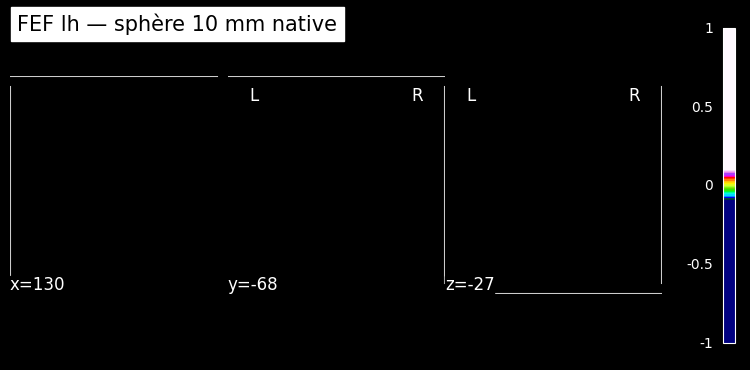

In [6]:
def sphere_mask_native(coords_ras: list[float], radius_mm: float,
                        ref_img: nib.Nifti1Image) -> nib.Nifti1Image:
    """Masque sphérique centré sur des coordonnées RAS (espace FreeSurfer natif)."""
    from nilearn.image import new_img_like
    affine = ref_img.affine
    shape  = ref_img.shape[:3]

    vox_centre = (np.linalg.inv(affine) @ np.append(coords_ras, 1))[:3]
    voxel_size = float(np.abs(np.diag(affine)[:3]).mean())
    radius_vox = radius_mm / voxel_size

    ii, jj, kk = np.ogrid[:shape[0], :shape[1], :shape[2]]
    dist_sq = ((ii - vox_centre[0])**2 +
               (jj - vox_centre[1])**2 +
               (kk - vox_centre[2])**2)
    data = (dist_sq <= radius_vox**2).astype(np.uint8)
    return new_img_like(ref_img, data, affine=affine)


# FEF gauche — coordonnées RAS approximatives
FEF_RAS = [-28, -8, 54]
FEF_sphere = sphere_mask_native(FEF_RAS, radius_mm=10.0, ref_img=t1_fs)
mask_path_FEF = MASKS_OUT / 'FEF_lh_sphere_native.nii.gz'
nib.save(FEF_sphere, mask_path_FEF)

plotting.plot_roi(FEF_sphere, bg_img=t1_fs,
                  title='FEF lh — sphère 10 mm native', display_mode='ortho')
plotting.show()

---
## D — Intégration simnibs-reader — espace natif

Les e-fields dans `subject_volumes/` sont en espace sujet SimNIBS,
qui peut différer légèrement de l'espace FreeSurfer (grille voxel différente).

> `simnibs-reader` **gère le resampling automatiquement** dans `get_roi()` :
> si l'affine du masque diffère de celui de l'e-field, il rééchantillonne
> le masque sur la grille de l'e-field avant l'extraction.

In [15]:
# Charger la simulation
sim = snr.simulation(SIMU_DIR)
# print(sim.tree())
# print('Champs disponibles :', sim.available_fields)

In [16]:
# E-field magnitude en espace natif
efield_native = sim.magnE_native
print(efield_native)           # EField — pas encore chargé
print(efield_native.shape)     # chargement ici

# ── Option 1 : masque volumétrique FreeSurfer (aparc+aseg) ──────────────
roi_M1 = efield_native.get_roi(mask=mask_path_M1)
print(roi_M1)
print('Stats M1 native :', roi_M1.stats())

# # ── Option 2 : masque surfacique projeté en volume ───────────────────────
# roi_M1_surf = efield_native.get_roi(mask=mask_path_M1_surf)
# print('Stats M1 surface :', roi_M1_surf.stats())

# # ── Option 3 : sphère native ─────────────────────────────────────────────
# roi_FEF = efield_native.get_roi(mask=mask_path_FEF)
# print('Stats FEF sphère :', roi_FEF.stats())

EField('0001_TDCS_1_scalar_magnE.nii.gz')
(176, 256, 256)
ROI(n_voxels=10676, mean=0.0359)
Stats M1 native : {'mean': 0.03586572563536004, 'median': 0.0, 'std': 0.06074996279680487, 'min': 0.0, 'max': 0.28214970231056213, 'p5': 0.0, 'p95': 0.15768110752105713, 'n_voxels': 10676}


In [ ]:
# Post-processing + export
cleaned = roi_M1.postprocess(smooth_fwhm=2.0, outlier_method='iqr')
print(cleaned)

cleaned.save(
    'results/sub-0003_M1_lh_native',
    metrics=['mean', 'median', 'std', 'n_voxels'],
    format='tsv',
)
cleaned.save_nifti('results/sub-0003_M1_lh_native_cleaned.nii.gz')

---
## E — Intégration simnibs-reader — espace MNI

Les e-fields dans `mni_volumes/` sont en espace MNI.
Les masques FreeSurfer (espace natif) doivent d'abord être
**warpés vers MNI** via le champ de déformation SimNIBS
(`toMNI/Conform2MNI_nonl.nii.gz`).

Alternative plus simple : utiliser directement
`efield.get_roi(coords=[x,y,z], radius=10)` qui travaille nativement en MNI.

In [ ]:
import ants

def warp_fs_mask_to_mni(mask_path: Path, m2m_dir: Path,
                         out_path: Path) -> Path:
    """Warpe un masque FreeSurfer natif vers MNI via le warp SimNIBS.

    Utilise ANTsPy + le champ Conform2MNI_nonl.nii.gz produit par charm.
    """
    seg = snr.segmentation(m2m_dir)
    warp = str(seg.warp_conform_to_mni)      # toMNI/Conform2MNI_nonl.nii.gz
    t1   = str(seg.t1)                       # T1.nii.gz — image fixe MNI

    moving = ants.image_read(str(mask_path))
    fixed  = ants.image_read(t1)

    warped = ants.apply_transforms(
        fixed=fixed,
        moving=moving,
        transformlist=[warp],
        interpolator='nearestNeighbor',      # masque binaire
    )
    ants.image_write(warped, str(out_path))
    return out_path


# Warper le masque M1 FreeSurfer → MNI
mask_M1_mni = MASKS_OUT / 'M1_lh_MNI.nii.gz'
warp_fs_mask_to_mni(mask_path_M1, M2M_DIR, mask_M1_mni)
print(f'Masque MNI sauvegardé : {mask_M1_mni}')

In [ ]:
# E-field magnitude en espace MNI
efield_mni = sim.magnE
print(efield_mni.shape)

# ── Option 1 : masque FS warpé en MNI ───────────────────────────────────
roi_M1_mni = efield_mni.get_roi(mask=mask_M1_mni)
print('Stats M1 MNI :', roi_M1_mni.stats())

# ── Option 2 : sphère MNI directement (sans FreeSurfer) ─────────────────
# simnibs-reader construit la sphère sur la grille de l'e-field
FEF_MNI_COORDS = [28, -8, 54]   # coordonnées MNI standard FEF gauche
roi_FEF_mni = efield_mni.get_roi(coords=FEF_MNI_COORDS, radius=10.0)
print('Stats FEF MNI sphère :', roi_FEF_mni.stats())

# Post-processing + export
roi_M1_mni.postprocess(smooth_fwhm=2.0).save(
    'results/sub-0003_M1_lh_MNI',
    metrics=['mean', 'median', 'std', 'n_voxels'],
    format='tsv',
)